## Artificial Intelligence Course — Spring 2026 – Kanan Sultanov 606.23E
Laboratory Work 3. Linear classification (10 points) (Demo 06.04.2026 and 08.04.2026)

Task 3.1. In this task you need to apply linear classification using gradient descent method for minimization of Hinge Loss function and numpy library for classification of the breast cancer tumors into two classes: benign and malignant. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo 

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

%config InlineBackend.figure_format = 'retina'

In [2]:
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 

X = breast_cancer_wisconsin_original.data.features 
y = breast_cancer_wisconsin_original.data.targets 

Examine the dataset for missing values and columns of type object. If present, impute the missing values and convert object-type columns into numerical representations

In [3]:
X

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2
697,4,8,6,4,3,4.0,10,6,1


In [4]:
X.dtypes

Clump_thickness                  int64
Uniformity_of_cell_size          int64
Uniformity_of_cell_shape         int64
Marginal_adhesion                int64
Single_epithelial_cell_size      int64
Bare_nuclei                    float64
Bland_chromatin                  int64
Normal_nucleoli                  int64
Mitoses                          int64
dtype: object

In [5]:
X.isna().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

In [6]:
X.isna().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

In [7]:
X = X.fillna(X.median())

In [8]:
y

,Class
0,2
1,2
2,2
3,2
4,2
...,...
694,2
695,2
696,4
697,4


In [9]:
y.value_counts()

Class
2        458
4        241
Name: count, dtype: int64

In [10]:
#Convert input and ouptut values into numpy array

X = X.to_numpy()
y = y.to_numpy().flatten()

In [11]:
#change labels of the target parameter from (2, 4) to (-1, 1)
y = np.where(y == 2, -1, 1)

At this stage, the data can be scaled to improve model performance.

In [12]:
np.unique(y, return_counts=True)

(array([-1,  1]), array([458, 241]))

In [13]:
#Initialize the weights vector by setting all elements to zero or to any other chosen value

w = np.zeros(X.shape[1])

In [14]:
w

array([0., 0., 0., 0., 0., 0., 0., 0., 0.])

Split the dataset into two parts: training and testing. You can use train_test_split from the scikit-learn library.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

write the code for calculation of the function z = sum(x, w) 

In [16]:
#code for calculation of the z function

def z(x, w):
    return np.dot(x, w)

Implement code to calculate the Hinge Loss function and output the loss over all training examples using the initial weight values

In [17]:
#calculation of Loss function

def hinge_Loss(x, y, w):

    predictions = z(x, w)
    
    # Calculate the margins (y_i * y_pred_i)
    margins = y * predictions
    
    # Hinge Loss for each example: max(0, 1 - margin)
    losses = np.maximum(0, 1 - margins)

    return np.mean(losses)

In [18]:
print(hinge_Loss(X_train, y_train, w))

1.0


Write code to compute the gradient of the Hinge Loss function with respect to the weight vector w

In [19]:
#Gradient of Hinge Loss function

def grad_HL(x, y, w):
    
    predictions = np.dot(x, w)
    margins = y * predictions
    
    # если margin < 1, градиент по w равен -y * x
    # если margin >= 1, градиент равен 0
    indicator = np.where(margins < 1, -y, 0)
    
    grad = np.dot(x.T, indicator) / x.shape[0]
    
    return grad

In [20]:
print(grad_HL(X_train, y_train, w))

[-0.58282209 -1.44376278 -1.40695297 -0.99795501 -0.52760736 -1.91820041
 -0.83435583 -1.22290389 -0.19018405]


In [21]:
alpha = 0.001
iterations = 10001

print("Initial Loss:", hinge_Loss(X_train, y_train, w))

for i in range(iterations):
    grad = grad_HL(X_train, y_train, w)
    
    w = w - (alpha * grad)
    
    loss = hinge_Loss(X_train, y_train, w)
    
    if i % 1000 == 0:
        print(f"Iteration {i}, Loss: {loss}")

Initial Loss: 1.0
Iteration 0, Loss: 0.9884147607278324
Iteration 1000, Loss: 0.4389902727071229
Iteration 2000, Loss: 0.38714007134463135
Iteration 3000, Loss: 0.36753101567825375
Iteration 4000, Loss: 0.3600313941477319
Iteration 5000, Loss: 0.3559383701138741
Iteration 6000, Loss: 0.3533846504489349
Iteration 7000, Loss: 0.35178598701075914
Iteration 8000, Loss: 0.3506241149878079
Iteration 9000, Loss: 0.3497706265865395
Iteration 10000, Loss: 0.3491373990573786


In [22]:
w

array([-0.22765849,  0.58132515,  0.23185685, -0.0961002 , -0.63204908,
        0.55407362, -0.32699591,  0.2358773 , -0.29900613])

In [23]:
loss

np.float64(0.3491373990573786)

Assess the performance of the logistic regression model using appropriate evaluation metrics

In [24]:
 np.dot(X_test, w)[:50]

array([-1.0109182 , -1.62069734, -1.72003476,  4.95148875, -1.72003476,
       -1.26471779,  0.22180982,  4.5752045 ,  1.80099387, -0.19914724,
       -1.49237628,  3.99813292, -1.39303885, -0.61188753, -1.39303885,
        0.54725971, -0.61072597,  2.18156646,  0.85320654, -0.72097546,
        1.77785685, -0.3056728 , -0.30312679, -0.61072597,  5.51462986,
       -2.47435787, -1.29370143, -1.76317996, -0.76830675,  3.30783027,
       -1.15716155, -1.48590184, -1.62069734,  3.8752454 , -0.61072597,
       -1.61247853, -1.06604294, -2.32947853,  0.02132311,  5.59041309,
       -1.49237628, -0.80656033,  3.52652965, -0.93772188, -1.39303885,
       -1.84835583, -1.10328425, -0.44053988, -0.24215133, -4.70738037])

In [25]:
y_pred = np.where(np.dot(X_test, w) >= 0, 1, -1)

In [26]:
y_pred

array([-1, -1, -1,  1, -1, -1,  1,  1,  1, -1, -1,  1, -1, -1, -1,  1, -1,
        1,  1, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1,  1,
       -1, -1, -1, -1,  1,  1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  1, -1,  1, -1, -1,  1, -1, -1, -1,  1,  1, -1, -1, -1,  1,  1,
       -1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1, -1,
        1,  1, -1, -1,  1, -1, -1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,
       -1, -1,  1, -1, -1,  1,  1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1,
        1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1,
       -1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1, -1, -1,  1, -1,  1, -1,
        1, -1,  1,  1, -1, -1,  1,  1, -1, -1, -1,  1, -1,  1,  1, -1,  1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1,  1,  1,
       -1, -1, -1, -1, -1, -1])

In [27]:
np.unique(y_pred, return_counts=True)

(array([-1,  1]), array([139,  71]))

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.91      0.89      0.90       143
           1       0.77      0.82      0.80        67

    accuracy                           0.87       210
   macro avg       0.84      0.85      0.85       210
weighted avg       0.87      0.87      0.87       210



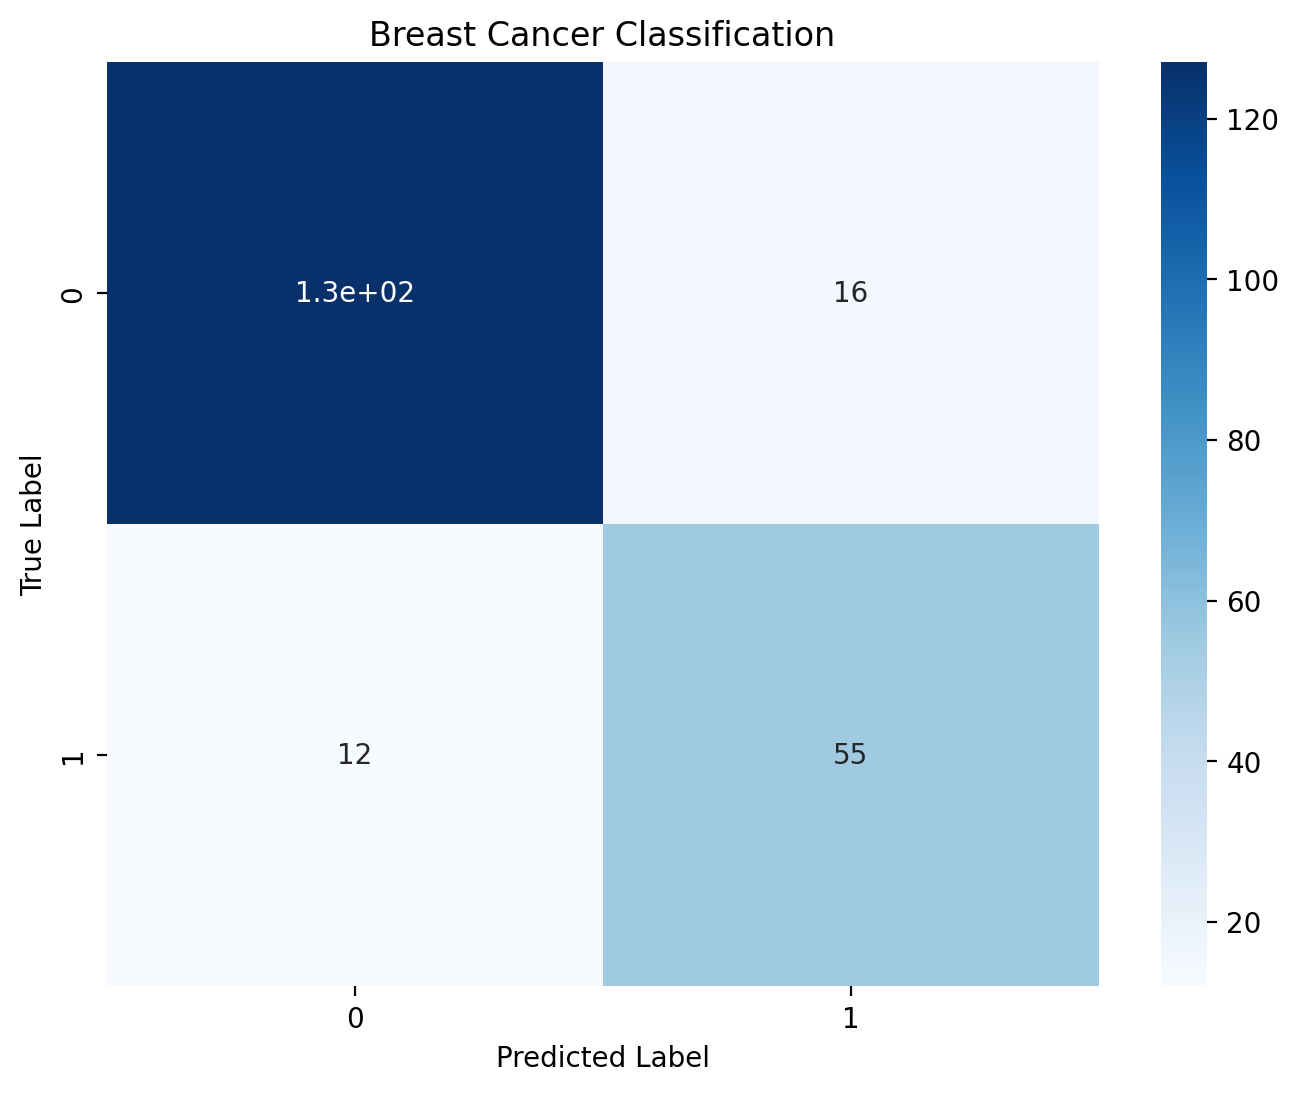

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.title('Breast Cancer Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

How do you evaluate the performance of an applied machine learning model? Which evaluation metrics are most important for the correct implementation of a given task, and why?

## Answer

The performance of an  classification model is evaluated by analyzing its confusion matrix, which tracks the correct predictions versus false alarms and missed detections. For the specific medical task of breast cancer diagnosis, Recall is the most critical metric because we cant miss a malignant tumor (a false negative).

# Task 3.2
In this task you will apply gradient descent method and minimization of cross entropy loss function to define class of the credit approval

In [30]:
credit_approval = fetch_ucirepo(id=27) 
  
X = credit_approval.data.features 
y = credit_approval.data.targets 

In [31]:
X

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,0,202.0,g,f,1,t,t,1.25,v,w,g,u,0.000,30.83,b
1,560,43.0,g,f,6,t,t,3.04,h,q,g,u,4.460,58.67,a
2,824,280.0,g,f,0,f,t,1.50,h,q,g,u,0.500,24.50,a
3,3,100.0,g,t,5,t,t,3.75,v,w,g,u,1.540,27.83,b
4,0,120.0,s,f,0,f,t,1.71,v,w,g,u,5.625,20.17,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0,260.0,g,f,0,f,f,1.25,h,e,p,y,10.085,21.08,b
686,394,200.0,g,t,2,t,f,2.00,v,c,g,u,0.750,22.67,a
687,1,200.0,g,t,1,t,f,2.00,ff,ff,p,y,13.500,25.25,a
688,750,280.0,g,f,0,f,f,0.04,v,aa,g,u,0.205,17.92,b


In [32]:
X.dtypes

A15      int64
A14    float64
A13     object
A12     object
A11      int64
A10     object
A9      object
A8     float64
A7      object
A6      object
A5      object
A4      object
A3     float64
A2     float64
A1      object
dtype: object

In [33]:
X.isna().sum()

A15     0
A14    13
A13     0
A12     0
A11     0
A10     0
A9      0
A8      0
A7      9
A6      9
A5      6
A4      6
A3      0
A2     12
A1     12
dtype: int64

In [34]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [35]:
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].mean())

/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/3520941156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].mean())


In [36]:
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/3616586795.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


In [37]:
encoder = LabelEncoder()

In [38]:
for col in categorical_cols:
    X[col] = encoder.fit_transform(X[col])

/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/2703265026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/2703265026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/2703265026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [39]:
X

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,0,202.0,0,0,1,1,1,1.25,7,12,0,1,0.000,30.83,1
1,560,43.0,0,0,6,1,1,3.04,3,10,0,1,4.460,58.67,0
2,824,280.0,0,0,0,0,1,1.50,3,10,0,1,0.500,24.50,0
3,3,100.0,0,1,5,1,1,3.75,7,12,0,1,1.540,27.83,1
4,0,120.0,2,0,0,0,1,1.71,7,12,0,1,5.625,20.17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0,260.0,0,0,0,0,0,1.25,3,4,2,2,10.085,21.08,1
686,394,200.0,0,1,2,1,0,2.00,7,1,0,1,0.750,22.67,0
687,1,200.0,0,1,1,1,0,2.00,2,5,2,2,13.500,25.25,0
688,750,280.0,0,0,0,0,0,0.04,7,0,0,1,0.205,17.92,1


In [40]:
X.isna().sum()

A15    0
A14    0
A13    0
A12    0
A11    0
A10    0
A9     0
A8     0
A7     0
A6     0
A5     0
A4     0
A3     0
A2     0
A1     0
dtype: int64

In [41]:
X.dtypes

A15      int64
A14    float64
A13      int64
A12      int64
A11      int64
A10      int64
A9       int64
A8     float64
A7       int64
A6       int64
A5       int64
A4       int64
A3     float64
A2     float64
A1       int64
dtype: object

In [42]:
y = encoder.fit_transform(y.values.ravel())

In [43]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [44]:
X = X.to_numpy(dtype=float)
y = np.array(y, dtype=float).flatten()

X = np.insert(X, 0, 1, axis=1)

In [45]:
X.shape

(690, 16)

In [46]:
#Initialize the weights vector by setting all elements to zero or to any other chosen value

w = np.zeros(X.shape[1])

Split the dataset into two parts: training and testing. You can use train_test_split from the scikit-learn library.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

write the code for calculation of the function z = sum(x, w) 

In [48]:
#code for calculation of the z function

def z(x, w):
    return np.dot(x, w)

In [49]:
#code for calculation of sigmoid function and decision boundary
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Implement code to calculate the Cross-entropy Loss function and output the loss over all training examples using the initial weight values

In [50]:
#calculation of Loss function

def ce_Loss(x, y, w):
    
    z_vec = z(x, w)
    predictions = sigmoid(z_vec)
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    loss = -y * np.log(predictions) - (1 - y) * np.log(1 - predictions)
    
    return np.mean(loss)

In [51]:
print(ce_Loss(X_train, y_train, w))

0.6931471805599453


In [52]:
#Gradient of Cross-entropy Loss function

def grad_ceL(x, y, w):
    
    z_vec = z(x, w)
    predictions = sigmoid(z_vec)
    
    error = predictions - y
    grad = np.dot(x.T, error) / x.shape[0]
    
    return grad

In [53]:
print(grad_ceL(X_train, y_train, w))

[-6.52173913e-02  3.76644928e+02 -1.73778468e+01 -3.83022774e-02
 -1.34575569e-02  8.44720497e-01  8.38509317e-02  1.48033126e-01
  3.59171843e-01 -3.16770186e-01 -1.27329193e-01 -1.12836439e-01
 -1.23188406e-01  1.50377847e-01 -9.08394437e-01 -5.59006211e-02]


In [54]:
alpha = 0.001
iterations = 10001

print("Initial Loss:", ce_Loss(X_train, y_train, w))

for i in range(iterations):
    
    grad = grad_ceL(X_train, y_train, w)
    w = w - (alpha * grad)
    loss = ce_Loss(X_train, y_train, w)
    
    if i % 1000 == 0:
        print(f"Iteration {i} | Loss: {loss:.6f}")

/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/745834425.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Initial Loss: 0.6931471805599453
Iteration 0 | Loss: 6.304535
Iteration 1000 | Loss: 6.994166
Iteration 2000 | Loss: 6.136742
Iteration 3000 | Loss: 4.844426
Iteration 4000 | Loss: 6.096948
Iteration 5000 | Loss: 8.394449
Iteration 6000 | Loss: 7.906906
Iteration 7000 | Loss: 7.740318
Iteration 8000 | Loss: 7.539575
Iteration 9000 | Loss: 7.199079
Iteration 10000 | Loss: 6.736725


In [55]:
w

array([ 0.23941906, -0.29736761,  0.05741934, -0.21445438, -0.10542986,
       -1.60931031, -0.19909321, -1.1188105 , -1.53664799,  0.6395056 ,
       -0.29111707,  0.59390351,  0.53982268,  0.02512196,  0.27978749,
        0.20053084])

Assess the performance of the logistic regression model using appropriate evaluation metrics

In [56]:
loss

np.float64(6.736724502350358)

In [57]:
z = np.dot(X_test, w)
y_pred_prob = sigmoid(z)
y_pred = np.where(y_pred_prob <= 0.5, 0, 1)

/var/folders/xl/gw34n52d6vdd73ntqx05njm40000gn/T/ipykernel_2182/745834425.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.71      0.64      0.67        97
         1.0       0.71      0.77      0.74       110

    accuracy                           0.71       207
   macro avg       0.71      0.71      0.71       207
weighted avg       0.71      0.71      0.71       207



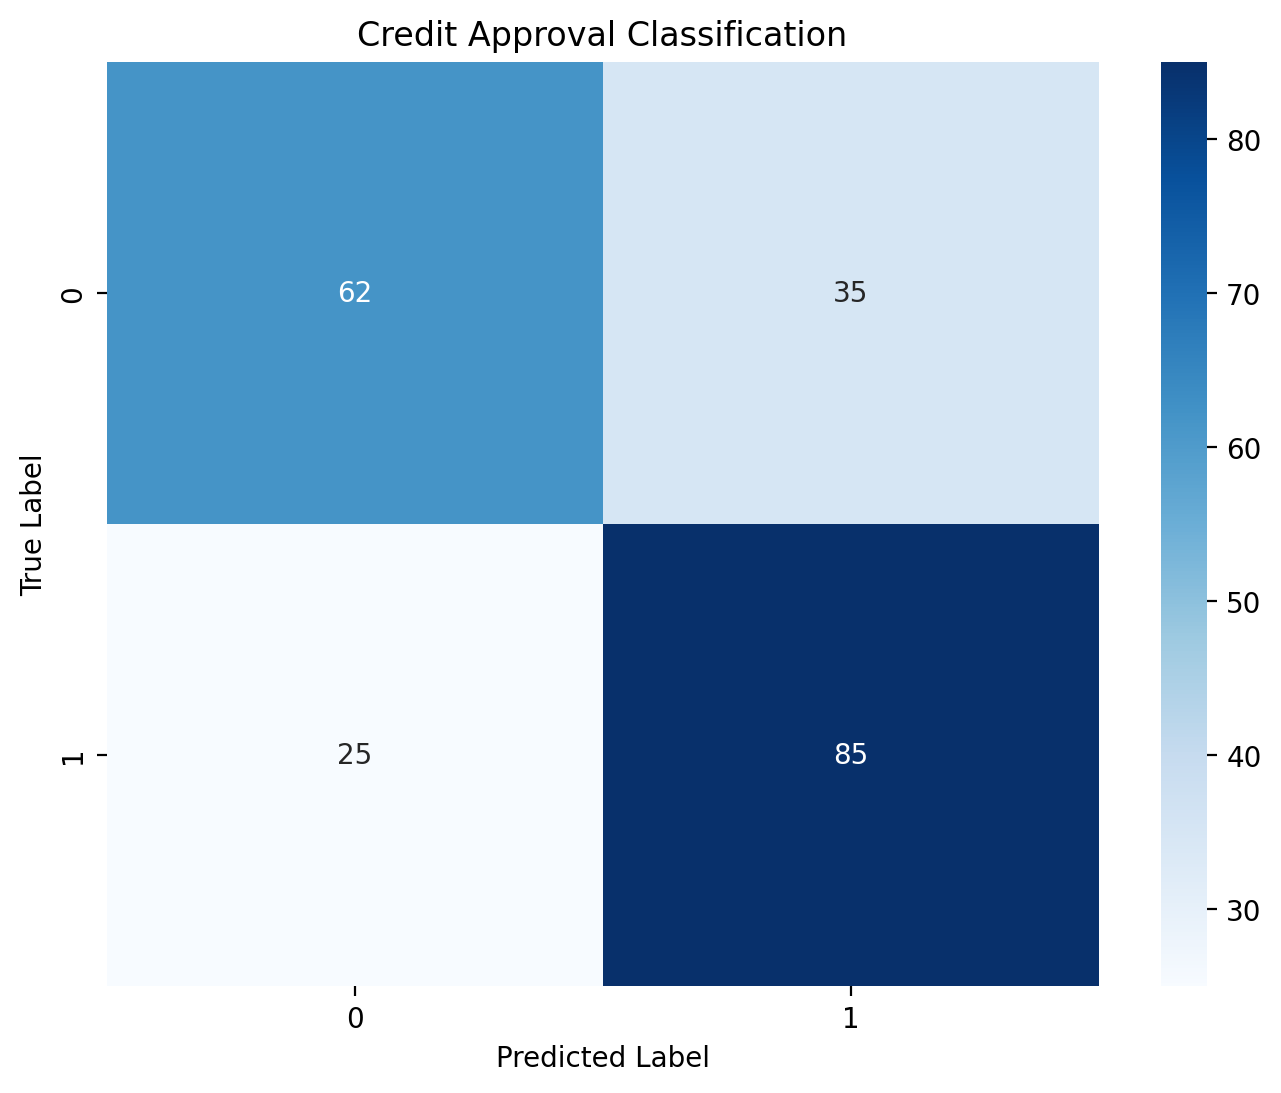

In [59]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.title('Credit Approval Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Open ended question: How do you evaluate the performance of an applied machine learning model? Which evaluation metrics are most important for the correct implementation of a given task, and why?

## Answer

Precision – because a False Positive—approving a loan for a high-risk customer who will default—results in direct and severe financial loss for bank. However, because strict models would cause the bank to reject safe, profitable customers (False Negatives), the F1-score is the most critical metric, as it mathematically forces the model to balance strict risk management with revenue generation.